# Decision Trees (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)


---

## 1. Introduction

### What are Decision Trees?

Decision Trees are versatile, non-parametric supervised learning algorithms used for **both classification and regression** tasks. They work by recursively partitioning the feature space into regions and making predictions based on the majority class (classification) or mean value (regression) in each region.

**Key characteristics:**
- **Supervised learning** algorithm for both classification and regression
- **Non-parametric** (makes no assumptions about data distribution)
- **Hierarchical structure** - mimics human decision-making
- **Highly interpretable** - can visualize and explain decisions
- **Handles non-linear relationships** naturally

**Historical Context:**
- Developed in the 1960s-1980s (various researchers)
- CART (Classification and Regression Trees) by Breiman et al. (1984)
- ID3, C4.5, C5.0 algorithms by Ross Quinlan
- Foundation for powerful ensemble methods (Random Forest, Gradient Boosting)

**Main Use Cases:**
- **Classification**: Medical diagnosis, customer churn, fraud detection
- **Regression**: House price prediction, demand forecasting
- Feature importance analysis
- Rule extraction for business logic
- Baseline for ensemble methods

**How it works (simplified):**
1. Start at root node with all data
2. Find the best feature and threshold to split data
3. Create child nodes based on split
4. Recursively repeat for each child until stopping criteria met
5. Leaf nodes contain final predictions

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3


---

## 2. Theory & Mathematics

### Core Concept: Recursive Binary Splitting

Decision trees work by recursively partitioning the feature space. At each node, the algorithm:
1. Evaluates all possible splits (feature + threshold)
2. Chooses the split that best reduces impurity/error
3. Creates two child nodes
4. Repeats until stopping criteria met

### Classification Trees

#### Impurity Measures

**1. Gini Impurity** (used by CART)

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} p_i^2$$

where:
- $p_i$ = proportion of class $i$ at node $t$
- $C$ = number of classes
- Range: [0, 0.5] for binary classification

**Properties:**
- Gini = 0: Pure node (all samples same class)
- Gini = 0.5: Maximum impurity (equal class distribution)

**2. Entropy** (used by ID3, C4.5)

$$\text{Entropy}(t) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

**Properties:**
- Entropy = 0: Pure node
- Entropy = 1: Maximum impurity (binary case)
- More computationally expensive than Gini (logarithm)

**3. Information Gain**

$$\text{IG}(D, f, \tau) = \text{Impurity}(D) - \frac{|D_{\text{left}}|}{|D|}\text{Impurity}(D_{\text{left}}) - \frac{|D_{\text{right}}|}{|D|}\text{Impurity}(D_{\text{right}})$$

where:
- $D$ = dataset at current node
- $f$ = feature to split on
- $\tau$ = threshold value
- $D_{\text{left}}$, $D_{\text{right}}$ = left and right child datasets

### Regression Trees

#### Error Measure: Mean Squared Error (MSE)

$$\text{MSE}(t) = \frac{1}{N_t} \sum_{i \in t} (y_i - \bar{y}_t)^2$$

where:
- $N_t$ = number of samples at node $t$
- $y_i$ = actual target value
- $\bar{y}_t$ = mean target value at node $t$

**Variance Reduction:**

$$\text{VR}(D, f, \tau) = \text{MSE}(D) - \frac{|D_{\text{left}}|}{|D|}\text{MSE}(D_{\text{left}}) - \frac{|D_{\text{right}}|}{|D|}\text{MSE}(D_{\text{right}})$$

**Leaf Node Prediction:**
- Classification: Majority class
- Regression: Mean of target values

### Splitting Algorithm (Greedy)

```
For each node:
  For each feature f:
    For each threshold τ:
      Split data into left (x[f] ≤ τ) and right (x[f] > τ)
      Calculate information gain / variance reduction
  Choose (f, τ) with maximum gain/reduction
  Create child nodes
  Recursively build subtrees
```

### Stopping Criteria

1. **Maximum depth** reached
2. **Minimum samples** for split not met
3. **Pure node** achieved (classification)
4. **No variance** in targets (regression)
5. **No improvement** in impurity/error

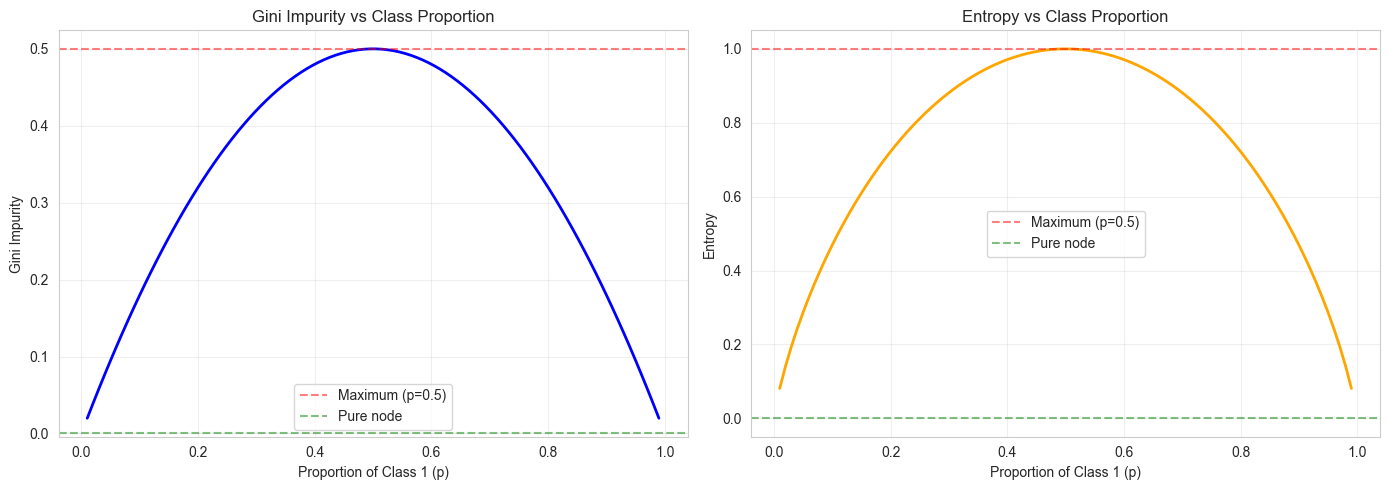


📊 Impurity Comparison:
  • At p=0.5 (maximum impurity):
    - Gini = 0.5000
    - Entropy = 1.0000
  • Both measure similar concept, Gini is faster to compute
  • In practice, they often give similar results


In [2]:
# Visualize Gini vs Entropy
p = np.linspace(0.01, 0.99, 100)
gini = 1 - p**2 - (1-p)**2
entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gini Impurity
axes[0].plot(p, gini, linewidth=2, color='blue')
axes[0].set_xlabel('Proportion of Class 1 (p)')
axes[0].set_ylabel('Gini Impurity')
axes[0].set_title('Gini Impurity vs Class Proportion')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Maximum (p=0.5)')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Pure node')
axes[0].legend()

# Entropy
axes[1].plot(p, entropy, linewidth=2, color='orange')
axes[1].set_xlabel('Proportion of Class 1 (p)')
axes[1].set_ylabel('Entropy')
axes[1].set_title('Entropy vs Class Proportion')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Maximum (p=0.5)')
axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Pure node')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Impurity Comparison:")
print(f"  • At p=0.5 (maximum impurity):")
print(f"    - Gini = {1 - 0.5**2 - 0.5**2:.4f}")
print(f"    - Entropy = {-0.5 * np.log2(0.5) - 0.5 * np.log2(0.5):.4f}")
print(f"  • Both measure similar concept, Gini is faster to compute")
print(f"  • In practice, they often give similar results")

---

## 3. Assumptions & Requirements

### Minimal Assumptions (Major Advantage!)

Unlike linear models, decision trees make **very few assumptions**:

✅ **No assumptions about:**
- Feature distributions
- Linear relationships
- Homoscedasticity
- Independence of errors
- Normality

### What Decision Trees DO Require:

1. **Labeled Data** (supervised learning)
   - Need (X, y) pairs for training

2. **Finite Feature Space**
   - Features must have finite unique values (or be binned)
   - Continuous features are automatically handled

3. **Consistent Labels**
   - Same input should have same output (deterministic relationship preferred)

4. **Sufficient Data**
   - Need enough samples to make meaningful splits
   - Too little data → overfitting risk

### Feature Requirements

#### ✅ What Works Well:
- **Numerical features** (continuous or discrete)
- **Categorical features** (after encoding)
- **Mixed feature types** (no scaling needed!)
- **Non-linear relationships**
- **Interactions** between features (automatically captured)
- **Missing values** (can be handled with special techniques)

#### ⚠️ What Needs Care:
- **High-dimensional sparse data** (many features, few samples)
- **Noisy data** (prone to overfitting)
- **Extrapolation** (can't predict outside training range)

### Key Differences from Linear Models

| Aspect | Decision Trees | Linear Models |
|--------|----------------|---------------|
| **Feature Scaling** | Not required | Required |
| **Feature Distribution** | Any | Often assume normal |
| **Relationship** | Non-linear | Linear |
| **Interactions** | Automatic | Manual (need to create) |
| **Interpretability** | Visual tree | Coefficients |
| **Overfitting Risk** | High (if deep) | Low (with regularization) |

---

## 4. When to Use This Algorithm

### ✅ Use Decision Trees When:

1. **Interpretability is crucial**
   - Need to explain model decisions to stakeholders
   - Medical diagnosis, credit approval, legal applications
   - Can visualize entire decision process

2. **Non-linear relationships exist**
   - Features interact in complex ways
   - Relationship between features and target is not linear
   - Threshold effects are important

3. **Mixed feature types**
   - Have both categorical and numerical features
   - Don't want to worry about feature scaling
   - Features on different scales

4. **Feature interactions matter**
   - Automatically captures interactions
   - Don't need to manually create interaction terms
   - Example: Age × Income effects

5. **Quick prototyping**
   - Fast to train
   - Good baseline model
   - Minimal preprocessing required

6. **Feature selection insight**
   - Identify important features
   - Understand which features drive predictions
   - Feature importance built-in

7. **Handling missing data** (with proper techniques)
   - Can learn to handle missing values in splits

### ❌ Avoid Decision Trees When:

1. **Linear relationships**
   - If relationship is truly linear, use linear models
   - Trees will create unnecessary complexity
   - Example: Simple price = cost × markup

2. **Smooth predictions needed**
   - Trees create step functions (piecewise constant)
   - Not suitable for smooth curves
   - Use regression with polynomial features instead

3. **Extrapolation required**
   - Trees can't predict outside training range
   - Will just use boundary values
   - Example: Predicting future trends

4. **Very high dimensional data**
   - Curse of dimensionality
   - Consider Random Forest instead
   - Or use feature selection first

5. **Small datasets**
   - Prone to overfitting
   - Need sufficient samples for reliable splits
   - Consider simpler models

6. **Need probabilistic predictions**
   - Tree probabilities are coarse (based on leaf samples)
   - Logistic regression gives smoother probabilities

### Classification vs Regression

| Task Type | When to Use Trees |
|-----------|-------------------|
| **Classification** | ✅ Multi-class problems<br>✅ Imbalanced classes (with class_weight)<br>✅ Non-linear decision boundaries<br>✅ Feature importance analysis |
| **Regression** | ✅ Non-linear relationships<br>✅ Threshold effects<br>⚠️ Smooth predictions needed<br>⚠️ Extrapolation required |

### Decision Tree vs Other Algorithms

**vs Linear Models:**
- Trees: Non-linear, no scaling, interpretable structure
- Linear: Fast, extrapolates, smooth predictions

**vs Neural Networks:**
- Trees: More interpretable, less data needed, no tuning
- NN: More flexible, better for complex patterns, needs more data

**vs SVM:**
- Trees: Faster, more interpretable, handles mixed types
- SVM: Better margin, kernel tricks, robust

**vs Ensemble Methods:**
- Trees: Single, interpretable, fast
- Ensembles: More accurate, robust, less interpretable

---

## 5. Implementation from Scratch (NumPy)

Let's implement both Decision Tree Classifier and Regressor from scratch to understand the internals.

In [3]:
# Import our from-scratch implementations
import sys
sys.path.append('../src')

from models.tree_models import DecisionTreeClassifierScratch, DecisionTreeRegressorScratch

print("✅ Imported custom Decision Tree implementations!")
print("\nAvailable classes:")
print("  • DecisionTreeClassifierScratch")
print("  • DecisionTreeRegressorScratch")

✅ Imported custom Decision Tree implementations!

Available classes:
  • DecisionTreeClassifierScratch
  • DecisionTreeRegressorScratch


### Classification Example (From Scratch)

In [4]:
# Generate classification dataset
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print("=" * 60)
print("DECISION TREE CLASSIFIER (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_clf)}")
print(f"  Test samples: {len(X_test_clf)}")
print(f"  Features: {X_train_clf.shape[1]}")
print(f"  Classes: {len(np.unique(y_clf))}")

# Train model with Gini
print("\n🌳 Training with Gini impurity...")
tree_gini_scratch = DecisionTreeClassifierScratch(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini'
)
tree_gini_scratch.fit(X_train_clf, y_train_clf)

# Train model with Entropy
print("🌳 Training with Entropy...")
tree_entropy_scratch = DecisionTreeClassifierScratch(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='entropy'
)
tree_entropy_scratch.fit(X_train_clf, y_train_clf)

# Evaluate
train_score_gini = tree_gini_scratch.score(X_train_clf, y_train_clf)
test_score_gini = tree_gini_scratch.score(X_test_clf, y_test_clf)
train_score_entropy = tree_entropy_scratch.score(X_train_clf, y_train_clf)
test_score_entropy = tree_entropy_scratch.score(X_test_clf, y_test_clf)

print("\n📈 Results (Gini):")
print(f"  Train Accuracy: {train_score_gini:.4f}")
print(f"  Test Accuracy:  {test_score_gini:.4f}")
print(f"  Tree Depth: {tree_gini_scratch.get_depth()}")
print(f"  Total Nodes: {tree_gini_scratch.count_nodes()}")

print("\n📈 Results (Entropy):")
print(f"  Train Accuracy: {train_score_entropy:.4f}")
print(f"  Test Accuracy:  {test_score_entropy:.4f}")
print(f"  Tree Depth: {tree_entropy_scratch.get_depth()}")
print(f"  Total Nodes: {tree_entropy_scratch.count_nodes()}")

print("\n💡 Both criteria give similar results!")

DECISION TREE CLASSIFIER (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10
  Classes: 2

🌳 Training with Gini impurity...
🌳 Training with Entropy...

📈 Results (Gini):
  Train Accuracy: 0.9425
  Test Accuracy:  0.9000
  Tree Depth: 5
  Total Nodes: 39

📈 Results (Entropy):
  Train Accuracy: 0.9425
  Test Accuracy:  0.9100
  Tree Depth: 5
  Total Nodes: 37

💡 Both criteria give similar results!


### Regression Example (From Scratch)

In [5]:
# Generate regression dataset
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=10,
    random_state=42
)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("=" * 60)
print("DECISION TREE REGRESSOR (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_reg)}")
print(f"  Test samples: {len(X_test_reg)}")
print(f"  Features: {X_train_reg.shape[1]}")

# Train model
print("\n🌳 Training regressor...")
tree_reg_scratch = DecisionTreeRegressorScratch(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)
tree_reg_scratch.fit(X_train_reg, y_train_reg)

# Predictions
y_train_pred_scratch = tree_reg_scratch.predict(X_train_reg)
y_test_pred_scratch = tree_reg_scratch.predict(X_test_reg)

# Evaluate
train_r2_scratch = tree_reg_scratch.score(X_train_reg, y_train_reg)
test_r2_scratch = tree_reg_scratch.score(X_test_reg, y_test_reg)
train_rmse_scratch = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_scratch))
test_rmse_scratch = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_scratch))

print("\n📈 Results:")
print(f"  Train R²:   {train_r2_scratch:.4f}")
print(f"  Test R²:    {test_r2_scratch:.4f}")
print(f"  Train RMSE: {train_rmse_scratch:.2f}")
print(f"  Test RMSE:  {test_rmse_scratch:.2f}")
print(f"  Tree Depth: {tree_reg_scratch.get_depth()}")
print(f"  Total Nodes: {tree_reg_scratch.count_nodes()}")

print("\n💡 Note: Decision trees create piecewise constant predictions")

DECISION TREE REGRESSOR (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10

🌳 Training regressor...

📈 Results:
  Train R²:   0.8276
  Test R²:    0.6414
  Train RMSE: 27.23
  Test RMSE:  40.09
  Tree Depth: 5
  Total Nodes: 49

💡 Note: Decision trees create piecewise constant predictions


---

## 6. Implementation with Scikit-learn

Now let's use scikit-learn's optimized implementations for both classification and regression.

### Classification with Scikit-learn


In [6]:
# Use same classification data from before
print("=" * 60)
print("DECISION TREE CLASSIFIER (SCIKIT-LEARN)")
print("=" * 60)

# Train model
tree_clf_sk = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)
tree_clf_sk.fit(X_train_clf, y_train_clf)

# Predictions
y_train_pred_clf = tree_clf_sk.predict(X_train_clf)
y_test_pred_clf = tree_clf_sk.predict(X_test_clf)
y_test_proba_clf = tree_clf_sk.predict_proba(X_test_clf)

# Evaluate
train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
test_acc = accuracy_score(y_test_clf, y_test_pred_clf)
precision = precision_score(y_test_clf, y_test_pred_clf)
recall = recall_score(y_test_clf, y_test_pred_clf)
f1 = f1_score(y_test_clf, y_test_pred_clf)

print("\n📈 Performance:")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:  {test_acc:.4f}")
print(f"  Precision:      {precision:.4f}")
print(f"  Recall:         {recall:.4f}")
print(f"  F1-Score:       {f1:.4f}")

# Tree structure
print(f"\n🌳 Tree Structure:")
print(f"  Max Depth: {tree_clf_sk.get_depth()}")
print(f"  Leaf Nodes: {tree_clf_sk.get_n_leaves()}")
print(f"  Total Nodes: {tree_clf_sk.tree_.node_count}")

# Feature importance
feature_importance_clf = tree_clf_sk.feature_importances_
print(f"\n🔍 Top 5 Important Features:")
top_indices = np.argsort(feature_importance_clf)[::-1][:5]
for idx in top_indices:
    print(f"  Feature {idx}: {feature_importance_clf[idx]:.4f}")

DECISION TREE CLASSIFIER (SCIKIT-LEARN)

📈 Performance:
  Train Accuracy: 0.9425
  Test Accuracy:  0.9000
  Precision:      0.9348
  Recall:         0.8600
  F1-Score:       0.8958

🌳 Tree Structure:
  Max Depth: 5
  Leaf Nodes: 20
  Total Nodes: 39

🔍 Top 5 Important Features:
  Feature 0: 0.3634
  Feature 5: 0.2807
  Feature 1: 0.1776
  Feature 8: 0.0784
  Feature 2: 0.0751


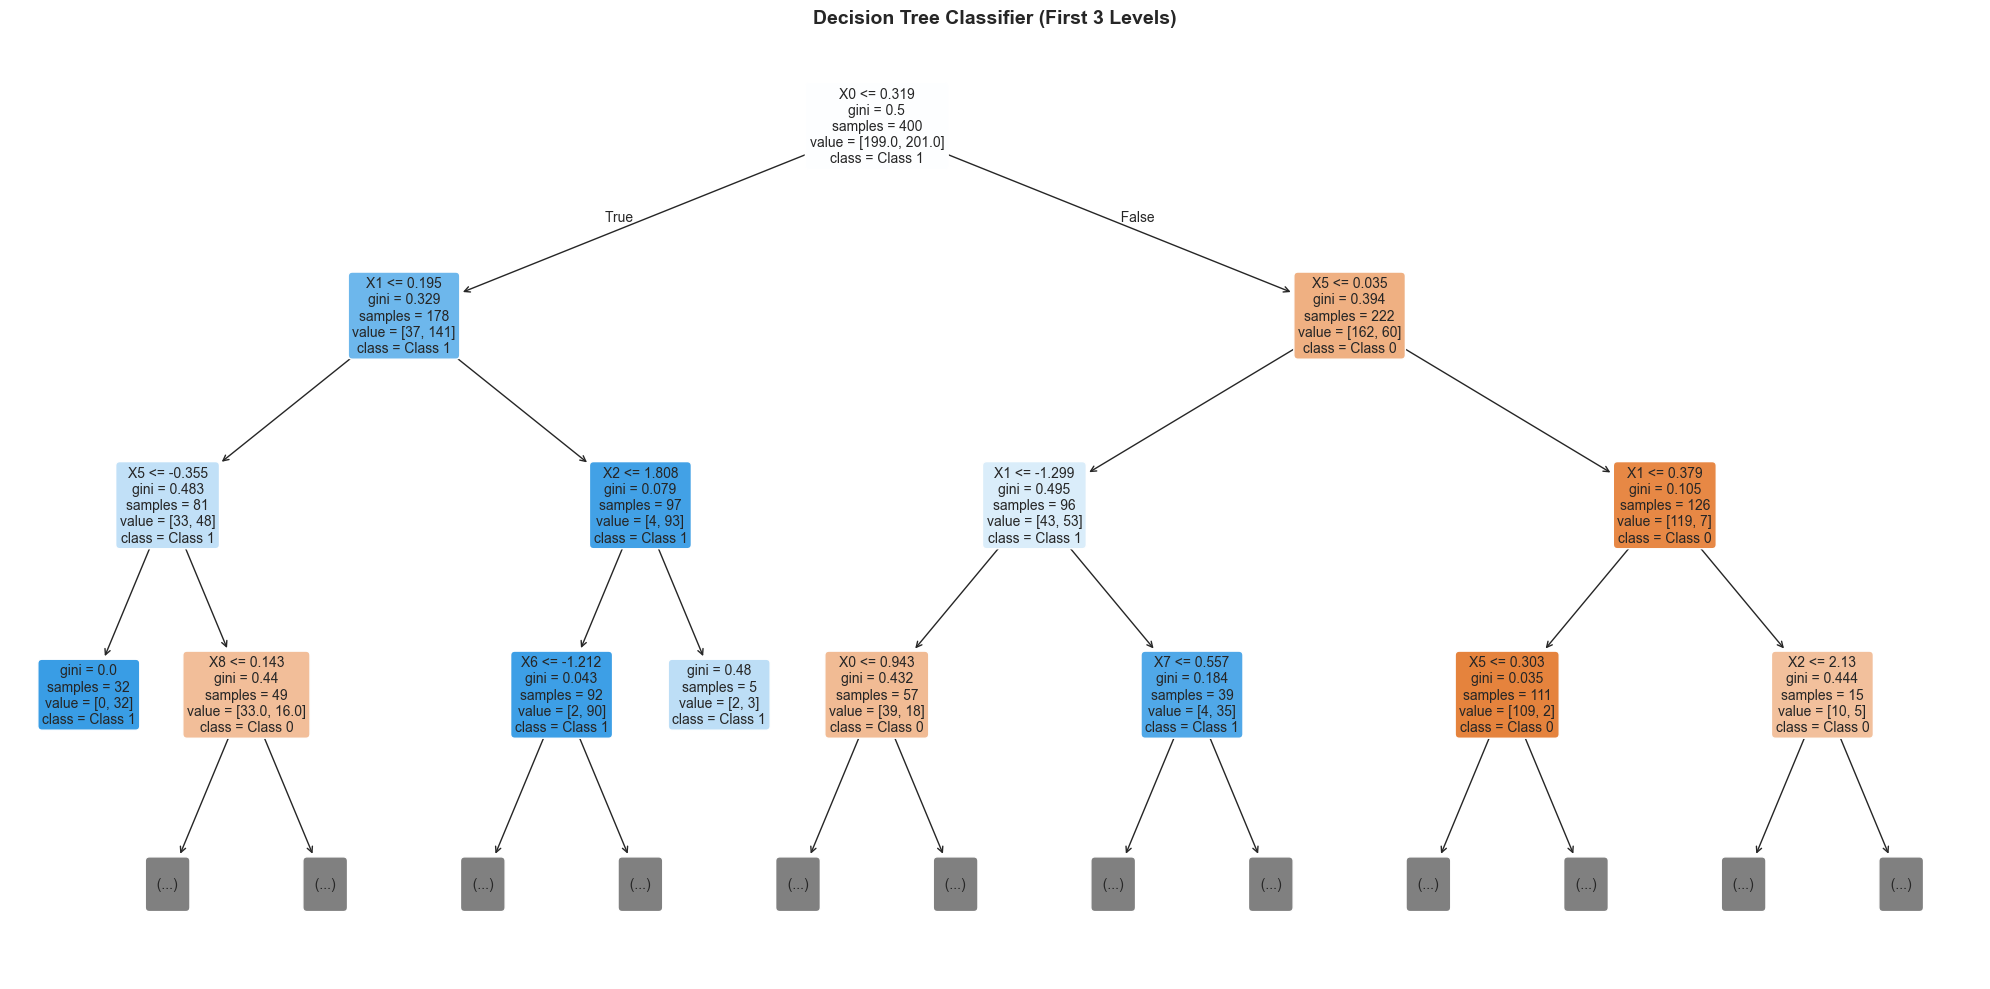

🌳 Tree visualization shows:
  • Each box = node
  • Top line = split condition (e.g., X0 <= 0.5)
  • gini = impurity
  • samples = number of samples at node
  • value = [class 0 count, class 1 count]
  • class = majority class


In [7]:
# Visualize tree (first 3 levels only for readability)
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf_sk,
    max_depth=3,
    feature_names=[f'X{i}' for i in range(X_train_clf.shape[1])],
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Classifier (First 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("🌳 Tree visualization shows:")
print("  • Each box = node")
print("  • Top line = split condition (e.g., X0 <= 0.5)")
print("  • gini = impurity")
print("  • samples = number of samples at node")
print("  • value = [class 0 count, class 1 count]")
print("  • class = majority class")

### Regression with Scikit-learn

In [8]:
# Use same regression data from before
print("=" * 60)
print("DECISION TREE REGRESSOR (SCIKIT-LEARN)")
print("=" * 60)

# Train model
tree_reg_sk = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
tree_reg_sk.fit(X_train_reg, y_train_reg)

# Predictions
y_train_pred_reg = tree_reg_sk.predict(X_train_reg)
y_test_pred_reg = tree_reg_sk.predict(X_test_reg)

# Evaluate
train_r2 = r2_score(y_train_reg, y_train_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)

print("\n📈 Performance:")
print(f"  Train R²:   {train_r2:.4f}")
print(f"  Test R²:    {test_r2:.4f}")
print(f"  Train RMSE: {train_rmse:.2f}")
print(f"  Test RMSE:  {test_rmse:.2f}")
print(f"  Test MAE:   {test_mae:.2f}")

# Tree structure
print(f"\n🌳 Tree Structure:")
print(f"  Max Depth: {tree_reg_sk.get_depth()}")
print(f"  Leaf Nodes: {tree_reg_sk.get_n_leaves()}")
print(f"  Total Nodes: {tree_reg_sk.tree_.node_count}")

# Feature importance
feature_importance_reg = tree_reg_sk.feature_importances_
print(f"\n🔍 Top 5 Important Features:")
top_indices = np.argsort(feature_importance_reg)[::-1][:5]
for idx in top_indices:
    print(f"  Feature {idx}: {feature_importance_reg[idx]:.4f}")

DECISION TREE REGRESSOR (SCIKIT-LEARN)

📈 Performance:
  Train R²:   0.8276
  Test R²:    0.6585
  Train RMSE: 27.23
  Test RMSE:  39.12
  Test MAE:   30.33

🌳 Tree Structure:
  Max Depth: 5
  Leaf Nodes: 25
  Total Nodes: 49

🔍 Top 5 Important Features:
  Feature 6: 0.5945
  Feature 7: 0.1583
  Feature 0: 0.1142
  Feature 8: 0.0710
  Feature 2: 0.0582


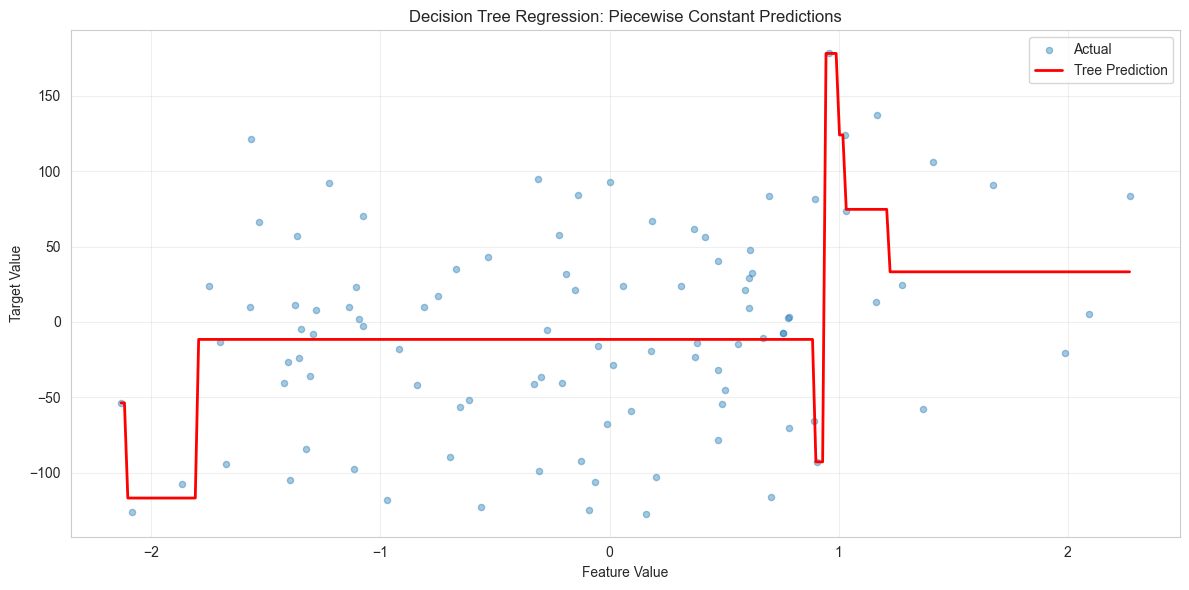

💡 Notice: Tree creates step functions (piecewise constant)
  • Each horizontal line = a leaf node prediction
  • Vertical jumps = decision boundaries
  • Cannot predict smooth curves


In [9]:
# Visualize predictions (showing piecewise constant nature)
# For single feature visualization
X_simple = X_test_reg[:, 0].reshape(-1, 1)
y_simple = y_test_reg

# Train simple tree on first feature only
tree_simple = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_simple.fit(X_simple, y_simple)

# Predictions on fine grid
X_grid = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
y_grid_pred = tree_simple.predict(X_grid)

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(X_simple, y_simple, alpha=0.4, label='Actual', s=20)
plt.plot(X_grid, y_grid_pred, 'r-', linewidth=2, label='Tree Prediction')
plt.xlabel('Feature Value')
plt.ylabel('Target Value')
plt.title('Decision Tree Regression: Piecewise Constant Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Notice: Tree creates step functions (piecewise constant)")
print("  • Each horizontal line = a leaf node prediction")
print("  • Vertical jumps = decision boundaries")
print("  • Cannot predict smooth curves")

---

## 7. Hyperparameter Tuning

Decision trees have several important hyperparameters that control complexity and prevent overfitting.

### Classification Hyperparameter Tuning

In [10]:
# Grid Search for Classification
print("=" * 60)
print("HYPERPARAMETER TUNING - CLASSIFICATION")
print("=" * 60)

param_grid_clf = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("\n🔍 Searching through parameter combinations...")
print(f"  Total combinations: {len(param_grid_clf['max_depth']) * len(param_grid_clf['min_samples_split']) * len(param_grid_clf['min_samples_leaf']) * len(param_grid_clf['criterion'])}")

grid_search_clf.fit(X_train_clf, y_train_clf)

print("\n✅ Best Parameters:")
for param, value in grid_search_clf.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📈 Best CV Accuracy: {grid_search_clf.best_score_:.4f}")

# Test best model
best_model_clf = grid_search_clf.best_estimator_
test_score_best = best_model_clf.score(X_test_clf, y_test_clf)
print(f"Test Accuracy: {test_score_best:.4f}")

HYPERPARAMETER TUNING - CLASSIFICATION

🔍 Searching through parameter combinations...
  Total combinations: 90

✅ Best Parameters:
  criterion: entropy
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 2

📈 Best CV Accuracy: 0.8700
Test Accuracy: 0.8700


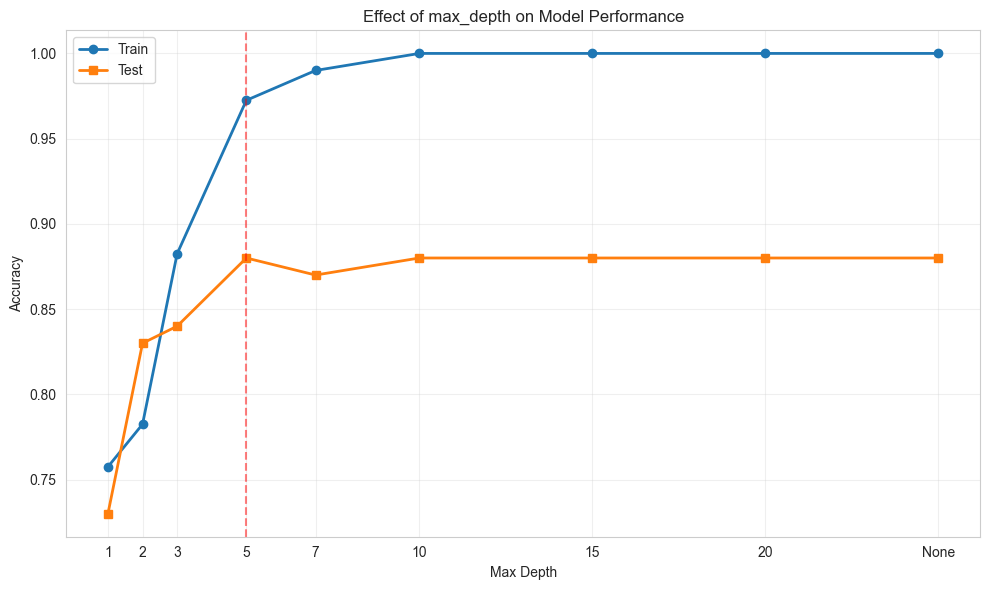

💡 Observations:
  • Shallow trees (depth 1-3): Underfit (low train & test scores)
  • Medium trees (depth 5-7): Good generalization
  • Deep trees (depth >10): Overfit (high train, lower test)
  • Best depth for test: 5


In [11]:
# Visualize effect of max_depth on performance
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_scores_depth = []
test_scores_depth = []

for depth in depths:
    tree_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_temp.fit(X_train_clf, y_train_clf)
    train_scores_depth.append(tree_temp.score(X_train_clf, y_train_clf))
    test_scores_depth.append(tree_temp.score(X_test_clf, y_test_clf))

# Convert None to large number for plotting
depths_plot = [d if d is not None else 25 for d in depths]

plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_scores_depth, 'o-', label='Train', linewidth=2)
plt.plot(depths_plot, test_scores_depth, 's-', label='Test', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths_plot, [str(d) if d != 25 else 'None' for d in depths_plot])
plt.axvline(x=depths_plot[np.argmax(test_scores_depth)], color='red', linestyle='--', alpha=0.5, label='Best Test')
plt.tight_layout()
plt.show()

print("💡 Observations:")
print("  • Shallow trees (depth 1-3): Underfit (low train & test scores)")
print("  • Medium trees (depth 5-7): Good generalization")
print("  • Deep trees (depth >10): Overfit (high train, lower test)")
print(f"  • Best depth for test: {depths[np.argmax(test_scores_depth)]}")

### Regression Hyperparameter Tuning

In [12]:
# Grid Search for Regression
print("=" * 60)
print("HYPERPARAMETER TUNING - REGRESSION")
print("=" * 60)

param_grid_reg = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("\n🔍 Searching through parameter combinations...")
grid_search_reg.fit(X_train_reg, y_train_reg)

print("\n✅ Best Parameters:")
for param, value in grid_search_reg.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📈 Best CV R²: {grid_search_reg.best_score_:.4f}")

# Test best model
best_model_reg = grid_search_reg.best_estimator_
test_r2_best = best_model_reg.score(X_test_reg, y_test_reg)
print(f"Test R²: {test_r2_best:.4f}")

HYPERPARAMETER TUNING - REGRESSION

🔍 Searching through parameter combinations...

✅ Best Parameters:
  max_depth: 7
  min_samples_leaf: 5
  min_samples_split: 20

📈 Best CV R²: 0.6285
Test R²: 0.6989


---

## 8. Complete Hyperparameter Reference

### Decision Tree Parameters

#### `max_depth` (int or None, default=None) **[MOST IMPORTANT]**
- **Description**: Maximum depth of the tree
- **Effect on Model**:
  - **Small depth** (e.g., 3-5): Simple model, prevents overfitting
    - Underfits if too small
    - Good for interpretability
  - **Large depth** (e.g., >15): Complex model, captures details
    - Overfits easily
    - Hard to interpret
  - **None**: Grows until all leaves are pure
    - Almost always overfits
- **Typical Range**: [3, 5, 7, 10, 15]
- **Tuning Strategy**: Start with 5-7, adjust based on overfitting
- **Example**: `DecisionTreeClassifier(max_depth=7)`

---

#### `min_samples_split` (int or float, default=2)
- **Description**: Minimum samples required to split an internal node
- **Effect**:
  - **Small** (e.g., 2): More splits, deeper tree, may overfit
  - **Large** (e.g., 20-50): Fewer splits, shallower tree, prevents overfitting
- **Typical Range**: [2, 10, 20, 50]
- **When to increase**: Large datasets, prevent overfitting
- **Example**: `DecisionTreeClassifier(min_samples_split=20)`

---

#### `min_samples_leaf` (int or float, default=1)
- **Description**: Minimum samples required in a leaf node
- **Effect**:
  - **Small** (e.g., 1): Fine-grained splits, may overfit
  - **Large** (e.g., 10-20): Coarser splits, smoother predictions
- **Typical Range**: [1, 5, 10, 20]
- **When to increase**: Prevent overfitting, need smoother predictions
- **Example**: `DecisionTreeClassifier(min_samples_leaf=10)`

---

#### `criterion` (str, default='gini' for classifier, 'squared_error' for regressor)
- **Classification Options**: 'gini', 'entropy'
  - **'gini'**: Faster, similar results to entropy
  - **'entropy'**: Slightly slower (logarithm), may prefer balanced splits
- **Regression Options**: 'squared_error', 'absolute_error', 'friedman_mse', 'poisson'
  - **'squared_error'**: Standard MSE
  - **'absolute_error'**: MAE, more robust to outliers
- **Example**: `DecisionTreeClassifier(criterion='entropy')`

---

#### `splitter` (str, default='best')
- **Options**: 'best', 'random'
- **Effect**:
  - **'best'**: Chooses best split (deterministic)
  - **'random'**: Chooses best random split (adds randomness)
- **When to use 'random'**: Large datasets, want diversity for ensembles
- **Example**: `DecisionTreeClassifier(splitter='random')`

---

#### `max_features` (int, float, str, or None, default=None)
- **Description**: Number of features to consider when looking for best split
- **Options**:
  - **None**: Use all features
  - **int**: Use specific number
  - **float**: Use fraction of features
  - **'sqrt'**: Use sqrt(n_features)
  - **'log2'**: Use log2(n_features)
- **When to use**: Very high-dimensional data, add randomness
- **Example**: `DecisionTreeClassifier(max_features='sqrt')`

---

#### `max_leaf_nodes` (int or None, default=None)
- **Description**: Maximum number of leaf nodes
- **Effect**: Alternative way to control tree complexity
- **When to use**: Want specific number of regions
- **Example**: `DecisionTreeClassifier(max_leaf_nodes=10)`

---

#### `min_impurity_decrease` (float, default=0.0)
- **Description**: Minimum impurity decrease required for split
- **Effect**: Prunes tree by requiring significant improvement
- **When to use**: Fine-grained control over pruning
- **Example**: `DecisionTreeClassifier(min_impurity_decrease=0.01)`

---

#### `class_weight` (dict, 'balanced', or None, default=None) **[Classification only]**
- **Description**: Weights for classes
- **Options**:
  - **None**: All classes have weight 1
  - **'balanced'**: Automatically adjusts for class imbalance
  - **dict**: Manual weights like {0: 1, 1: 3}
- **When to use**: Imbalanced datasets
- **Example**: `DecisionTreeClassifier(class_weight='balanced')`

---

#### `random_state` (int, default=None)
- **Description**: Seed for reproducibility
- **Effect**: Controls randomness in splits (when splitter='random')
- **Always set** for reproducible results
- **Example**: `DecisionTreeClassifier(random_state=42)`

---

### Parameter Combinations Guide

#### For Balanced Classification:
```python
DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)
```

#### For Imbalanced Classification:
```python
DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
```

#### For Regression:
```python
DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='squared_error',
    random_state=42
)
```

#### For Preventing Overfitting:
```python
DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    min_impurity_decrease=0.01,
    random_state=42
)
```

#### For Ensemble Building (Random Forest):
```python
DecisionTreeClassifier(
    max_depth=None,
    max_features='sqrt',
    min_samples_split=2,
    min_samples_leaf=1,
    splitter='random',
    random_state=42
)
```

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Always Control Tree Depth**
Decision trees will overfit if allowed to grow unconstrained.

```python
# Bad: No depth limit
tree = DecisionTreeClassifier()  # Will overfit!

# Good: Set reasonable depth
tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=5)
```

---

#### 2. **Use Cross-Validation for Hyperparameter Tuning**
```python
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")
```

---

#### 3. **Check for Overfitting**
```python
train_score = tree.score(X_train, y_train)
test_score = tree.score(X_test, y_test)

if train_score - test_score > 0.1:
    print("⚠️ Overfitting detected!")
    print("  • Reduce max_depth")
    print("  • Increase min_samples_split/leaf")
    print("  • Use ensemble methods")
```

---

#### 4. **Handle Imbalanced Data**
```python
# Check class distribution
print(np.bincount(y_train))

# Use class_weight if imbalanced
tree = DecisionTreeClassifier(class_weight='balanced')
```

---

#### 5. **Feature Importance Analysis**
```python
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature ranking:")
for i in range(min(10, len(indices))):
    print(f"{i+1}. Feature {indices[i]}: {importances[indices[i]]:.4f}")
```

---

#### 6. **No Need to Scale Features**
Unlike linear models, decision trees don't need feature scaling!

```python
# This is fine - no scaling needed
tree.fit(X_train, y_train)  # X_train can have mixed scales
```

---

### ❌ Common Mistakes

#### 1. **Not Setting max_depth (Overfitting)**
**Bad**:
```python
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
# Train: 1.00, Test: 0.75 - Clear overfit!
```

**Good**:
```python
tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=10)
tree.fit(X_train, y_train)
# Train: 0.88, Test: 0.85 - Good generalization
```

---

#### 2. **Using Single Tree for Production**
Single trees are unstable (high variance).

**Bad**:
```python
tree = DecisionTreeClassifier(max_depth=10)
# Small data changes can drastically change tree structure
```

**Good**:
```python
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)  # Ensemble of trees
# Much more stable and accurate
```

---

#### 3. **Ignoring Train-Test Gap**
```python
# If you see this:
print(f"Train Accuracy: 0.99")
print(f"Test Accuracy: 0.72")

# Don't ignore it! Signs of overfitting:
# 1. Reduce max_depth
# 2. Increase min_samples_split/leaf
# 3. Use pruning (min_impurity_decrease)
# 4. Switch to Random Forest
```

---

#### 4. **Using Trees for Extrapolation**
Trees can't predict outside training range!

**Bad**:
```python
# Train on ages 20-60
tree_reg.fit(X_train, y_train)
# Predict for age 80 - will just use boundary value (60)
```

**Good**:
```python
# Use linear models for extrapolation
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
```

---

#### 5. **Not Handling Class Imbalance**
```python
# 95% class 0, 5% class 1
# Bad: Tree will predict mostly class 0
tree = DecisionTreeClassifier()

# Good: Balance classes
tree = DecisionTreeClassifier(class_weight='balanced')
```

---

#### 6. **Expecting Smooth Predictions (Regression)**
Trees create piecewise constant predictions, not smooth curves.

**Solution**: Use ensemble methods (Random Forest, Gradient Boosting) for smoother predictions.

---

### Performance Optimization

#### Computational Complexity
- **Training**: O(n × m × log(n)) where n=samples, m=features
  - Greedy search through features and thresholds
  - Faster than SVMs, slower than linear models
- **Prediction**: O(log(n)) - very fast!
  - Just traverse tree from root to leaf

#### Memory Requirements
- Stores tree structure: O(nodes)
- Efficient for small-medium trees
- Can be large for deep trees

#### For Large Datasets
```python
# Limit tree growth
tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=100,
    max_leaf_nodes=100
)

# Or use sampling
from sklearn.utils import resample
X_sample, y_sample = resample(X_train, y_train, n_samples=10000)
tree.fit(X_sample, y_sample)
```

---

### Debugging Tips

#### Tree Not Learning?
1. **Check if labels are correct** (not all same class)
2. **Verify features are informative** (not all constant)
3. **Try different criterion** (gini vs entropy)
4. **Check for data leakage**

#### Poor Generalization?
1. **Reduce max_depth** (start with 5-7)
2. **Increase min_samples_split/leaf**
3. **Use cross-validation** to find best params
4. **Try ensemble methods** (Random Forest)
5. **Check for class imbalance** (use class_weight)

#### Tree Too Large?
1. **Set max_leaf_nodes** (e.g., 20-50)
2. **Increase min_impurity_decrease**
3. **Use cost-complexity pruning** (ccp_alpha)

---

### Cost-Complexity Pruning
Scikit-learn supports post-pruning using cost-complexity parameter.

```python
# Find optimal ccp_alpha
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Try different alphas
for ccp_alpha in ccp_alphas[::5]:  # Sample every 5th
    tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=5)
    print(f"Alpha: {ccp_alpha:.4f}, CV Score: {scores.mean():.3f}")
```


---

## 10. Real-world Examples

### Example 1: Customer Churn Prediction (Classification)

In [13]:
# Simulate customer churn dataset
np.random.seed(42)

n_customers = 1000
age = np.random.randint(18, 70, n_customers)
tenure = np.random.randint(0, 120, n_customers)  # months
monthly_charges = np.random.uniform(20, 120, n_customers)
total_charges = monthly_charges * tenure + np.random.normal(0, 100, n_customers)
contract_type = np.random.choice([0, 1, 2], n_customers)  # 0: month-to-month, 1: 1-year, 2: 2-year
num_services = np.random.randint(0, 6, n_customers)

# Create churn based on features (synthetic logic)
churn_prob = (
    0.3  # base probability
    - 0.003 * age  # older customers less likely to churn
    - 0.004 * tenure  # longer tenure = less churn
    + 0.002 * monthly_charges  # higher charges = more churn
    - 0.1 * contract_type  # longer contracts = less churn
    - 0.05 * num_services  # more services = less churn
    + np.random.normal(0, 0.1, n_customers)  # random noise
)
churn = (churn_prob > 0.3).astype(int)

X_churn = np.column_stack([age, tenure, monthly_charges, total_charges, contract_type, num_services])
feature_names_churn = ['Age', 'Tenure (months)', 'Monthly Charges', 'Total Charges', 'Contract Type', 'Num Services']

# Split data
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, churn, test_size=0.3, random_state=42, stratify=churn
)

print("=" * 60)
print("REAL-WORLD EXAMPLE: CUSTOMER CHURN PREDICTION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total customers: {n_customers}")
print(f"  Training: {len(X_train_churn)}")
print(f"  Test: {len(X_test_churn)}")
print(f"  Features: {', '.join(feature_names_churn)}")

print(f"\n⚖️ Churn Distribution:")
churn_counts = np.bincount(churn)
print(f"  Retained (0): {churn_counts[0]} ({churn_counts[0]/len(churn):.1%})")
print(f"  Churned (1): {churn_counts[1]} ({churn_counts[1]/len(churn):.1%})")

REAL-WORLD EXAMPLE: CUSTOMER CHURN PREDICTION

📊 Dataset:
  Total customers: 1000
  Training: 700
  Test: 300
  Features: Age, Tenure (months), Monthly Charges, Total Charges, Contract Type, Num Services

⚖️ Churn Distribution:
  Retained (0): 982 (98.2%)
  Churned (1): 18 (1.8%)



📈 Performance:
  Accuracy:  0.9533
  Precision: 0.1538
  Recall:    0.4000
  F1-Score:  0.2222


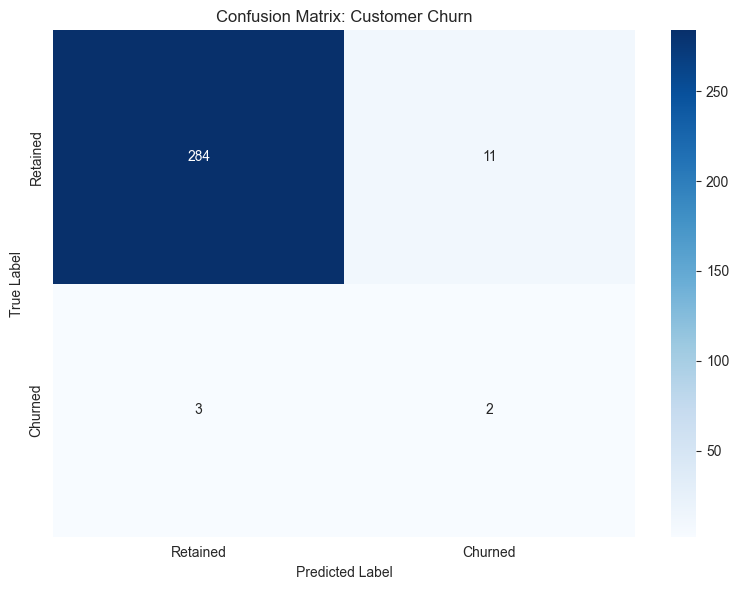

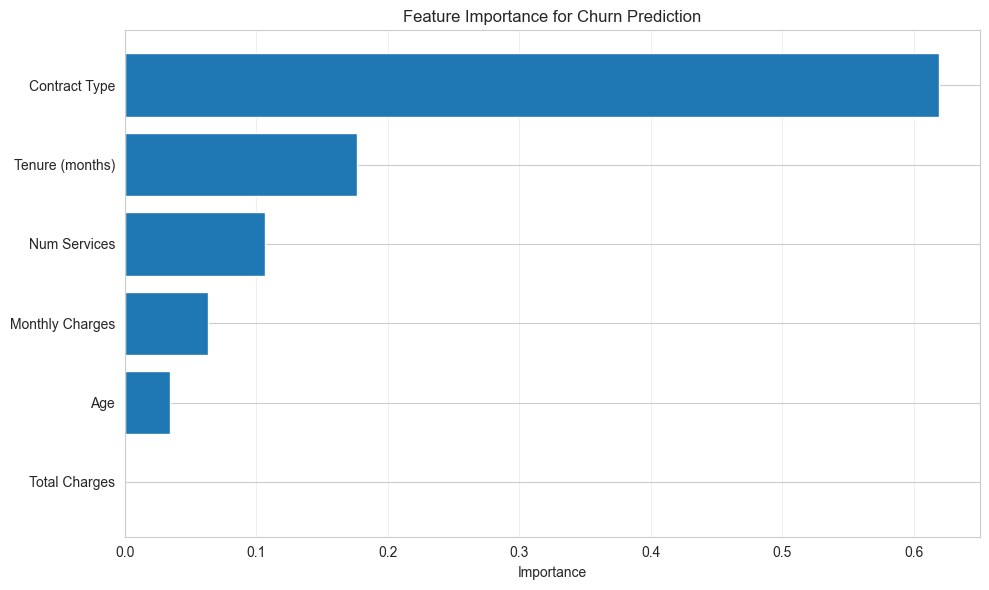


🔍 Top Churn Predictors:
  • Contract Type: 0.6196
  • Tenure (months): 0.1765
  • Num Services: 0.1062


In [14]:
# Train decision tree
tree_churn = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',  # Handle any imbalance
    random_state=42
)
tree_churn.fit(X_train_churn, y_train_churn)

# Predictions
y_pred_churn = tree_churn.predict(X_test_churn)
y_proba_churn = tree_churn.predict_proba(X_test_churn)[:, 1]

# Evaluate
print("\n📈 Performance:")
print(f"  Accuracy:  {accuracy_score(y_test_churn, y_pred_churn):.4f}")
print(f"  Precision: {precision_score(y_test_churn, y_pred_churn):.4f}")
print(f"  Recall:    {recall_score(y_test_churn, y_pred_churn):.4f}")
print(f"  F1-Score:  {f1_score(y_test_churn, y_pred_churn):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_churn, y_pred_churn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix: Customer Churn')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature importance
importance_churn = pd.DataFrame({
    'Feature': feature_names_churn,
    'Importance': tree_churn.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_churn['Feature'], importance_churn['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Churn Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🔍 Top Churn Predictors:")
for idx, row in importance_churn.head(3).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

### Example 2: House Price Prediction (Regression)

In [15]:
# Simulate house price dataset
np.random.seed(42)

n_houses = 500
sqft = np.random.randint(800, 4000, n_houses)
bedrooms = np.random.randint(1, 6, n_houses)
bathrooms = np.random.randint(1, 4, n_houses)
age = np.random.randint(0, 50, n_houses)
garage = np.random.randint(0, 3, n_houses)
location_score = np.random.uniform(1, 10, n_houses)  # 1=bad, 10=excellent

# Create price based on features
price = (
    100  # base price in $1000s
    + 0.15 * sqft  # $150 per sqft
    + 20 * bedrooms
    + 15 * bathrooms
    - 2 * age  # depreciation
    + 10 * garage
    + 30 * location_score
    + np.random.normal(0, 30, n_houses)  # noise
)

X_house = np.column_stack([sqft, bedrooms, bathrooms, age, garage, location_score])
feature_names_house = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Garage', 'Location Score']

# Split data
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, price, test_size=0.3, random_state=42
)

print("=" * 60)
print("REAL-WORLD EXAMPLE: HOUSE PRICE PREDICTION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total houses: {n_houses}")
print(f"  Training: {len(X_train_house)}")
print(f"  Test: {len(X_test_house)}")
print(f"  Features: {', '.join(feature_names_house)}")
print(f"\n💰 Price Range:")
print(f"  Min: ${price.min():.0f}k")
print(f"  Max: ${price.max():.0f}k")
print(f"  Mean: ${price.mean():.0f}k")
print(f"  Median: ${np.median(price):.0f}k")

REAL-WORLD EXAMPLE: HOUSE PRICE PREDICTION

📊 Dataset:
  Total houses: 500
  Training: 350
  Test: 150
  Features: Sqft, Bedrooms, Bathrooms, Age, Garage, Location Score

💰 Price Range:
  Min: $264k
  Max: $1097k
  Mean: $680k
  Median: $667k



📈 Performance:
  R² Score: 0.8615
  RMSE: $59.52k
  MAE: $47.85k
  Mean Price: $679.82k
  RMSE/Mean: 8.76%


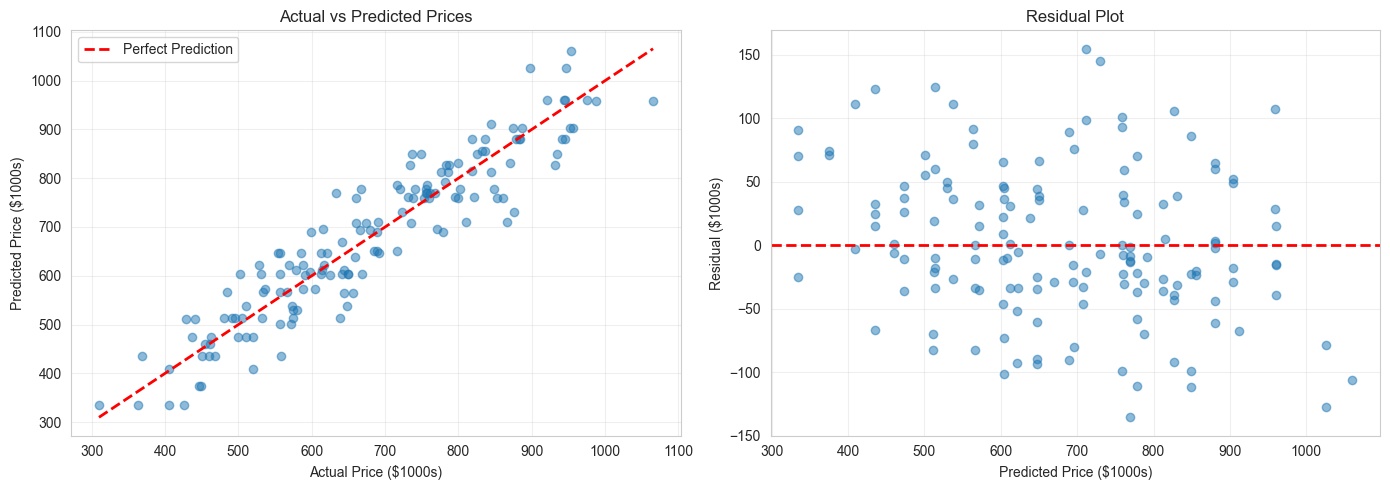

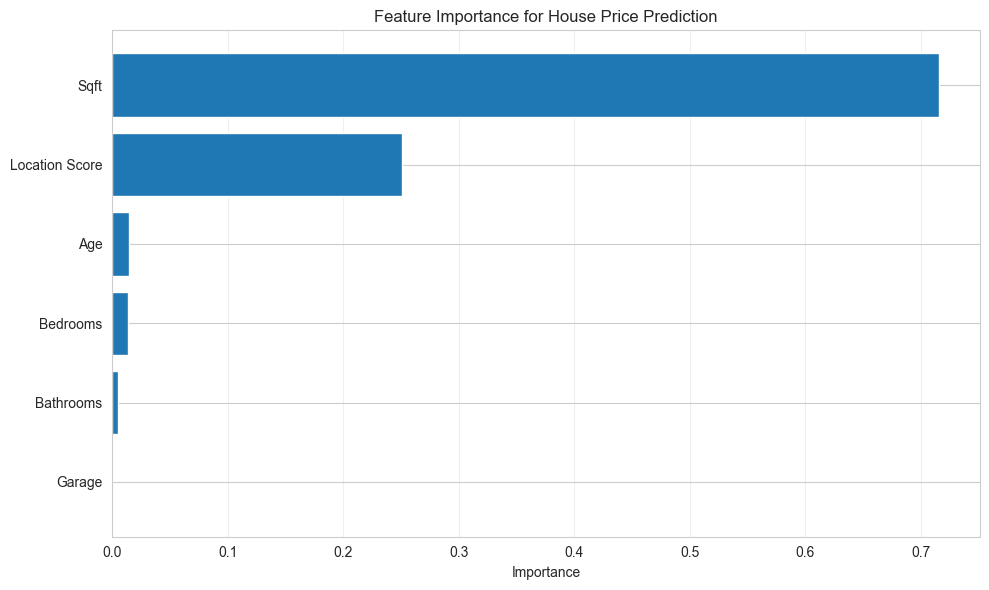


🔍 Top Price Predictors:
  • Sqft: 0.7156
  • Location Score: 0.2513
  • Age: 0.0147


In [16]:
# Train decision tree regressor
tree_house = DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
tree_house.fit(X_train_house, y_train_house)

# Predictions
y_pred_house = tree_house.predict(X_test_house)

# Evaluate
r2 = r2_score(y_test_house, y_pred_house)
rmse = np.sqrt(mean_squared_error(y_test_house, y_pred_house))
mae = mean_absolute_error(y_test_house, y_pred_house)

print("\n📈 Performance:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: ${rmse:.2f}k")
print(f"  MAE: ${mae:.2f}k")
print(f"  Mean Price: ${y_test_house.mean():.2f}k")
print(f"  RMSE/Mean: {rmse/y_test_house.mean():.2%}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_house, y_pred_house, alpha=0.5)
axes[0].plot([y_test_house.min(), y_test_house.max()], 
            [y_test_house.min(), y_test_house.max()], 
            'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_house - y_pred_house
axes[1].scatter(y_pred_house, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residual ($1000s)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
importance_house = pd.DataFrame({
    'Feature': feature_names_house,
    'Importance': tree_house.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_house['Feature'], importance_house['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for House Price Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🔍 Top Price Predictors:")
for idx, row in importance_house.head(3).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

---

## 11. Comparison with Other Algorithms

### When to Choose Decision Trees vs Alternatives

| Aspect | Decision Trees | Linear Models | SVM | Random Forest | Neural Networks |
|--------|----------------|---------------|-----|---------------|-----------------|
| **Interpretability** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐ | ⭐⭐ | ⭐ |
| **Training Speed** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Prediction Speed** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Non-linear** | ⭐⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Feature Scaling** | Not needed | Required | Required | Not needed | Required |
| **Overfitting Risk** | High | Low | Medium | Low | High |
| **Small Data (<1000)** | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ | ⭐ |
| **Large Data (>100k)** | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Mixed Features** | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Missing Values** | ⭐⭐⭐⭐ | ⭐ | ⭐ | ⭐⭐⭐⭐ | ⭐ |
| **Extrapolation** | ❌ No | ✅ Yes | ❌ No | ❌ No | ⚠️ Limited |
| **Ensemble Ready** | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | N/A | ⭐⭐ |

### Practical Comparison

In [17]:
# Compare algorithms on classification task
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import time

print("=" * 60)
print("ALGORITHM COMPARISON - CLASSIFICATION")
print("=" * 60)

classifiers = {
    'Decision Tree': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1),
    'Naive Bayes': GaussianNB()
}

results_comp = []

for name, clf in classifiers.items():
    # Time training
    start = time.time()
    clf.fit(X_train_clf, y_train_clf)
    train_time = time.time() - start
    
    # Time prediction
    start = time.time()
    y_pred = clf.predict(X_test_clf)
    pred_time = time.time() - start
    
    # Metrics
    acc = accuracy_score(y_test_clf, y_pred)
    
    results_comp.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Train Time (s)': train_time,
        'Pred Time (ms)': pred_time * 1000
    })

# Display results
df_comp = pd.DataFrame(results_comp)
print("\n" + df_comp.to_string(index=False))

print("\n" + "=" * 60)
print("💡 Key Insights:")
print("=" * 60)
print("✓ Decision Tree:")
print("  • Fast to train and predict")
print("  • Highly interpretable (can visualize)")
print("  • Handles non-linear patterns")
print("  • Can overfit if not tuned")
print("\n✓ Logistic Regression:")
print("  • Fastest overall")
print("  • Good for linear relationships")
print("  • Requires feature scaling")
print("\n✓ Random Forest:")
print("  • Usually best accuracy")
print("  • Ensemble of trees (more stable)")
print("  • Less interpretable")
print("\n✓ Naive Bayes:")
print("  • Very fast")
print("  • Assumes feature independence")

ALGORITHM COMPARISON - CLASSIFICATION

          Algorithm  Accuracy  Train Time (s)  Pred Time (ms)
      Decision Tree      0.87        0.002999        0.000000
Logistic Regression      0.82        0.012666        0.000000
      Random Forest      0.91        0.134574       17.556429
        Naive Bayes      0.85        0.000000        0.000000

💡 Key Insights:
✓ Decision Tree:
  • Fast to train and predict
  • Highly interpretable (can visualize)
  • Handles non-linear patterns
  • Can overfit if not tuned

✓ Logistic Regression:
  • Fastest overall
  • Good for linear relationships
  • Requires feature scaling

✓ Random Forest:
  • Usually best accuracy
  • Ensemble of trees (more stable)
  • Less interpretable

✓ Naive Bayes:
  • Very fast
  • Assumes feature independence


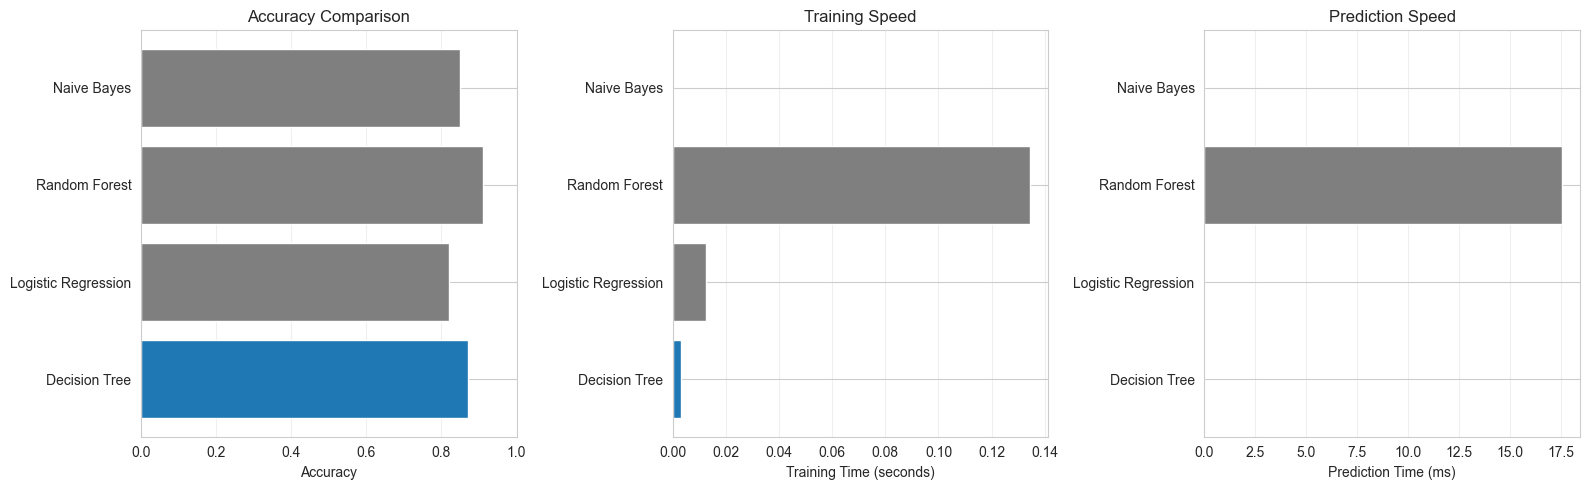

In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algorithms = df_comp['Algorithm']
accuracies = df_comp['Accuracy']
train_times = df_comp['Train Time (s)']
pred_times = df_comp['Pred Time (ms)']

colors = ['#1f77b4' if 'Tree' in alg else '#7f7f7f' for alg in algorithms]

# Accuracy comparison
axes[0].barh(algorithms, accuracies, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlim([0, 1])
axes[0].grid(True, alpha=0.3, axis='x')

# Training time
axes[1].barh(algorithms, train_times, color=colors)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Speed')
axes[1].grid(True, alpha=0.3, axis='x')

# Prediction time
axes[2].barh(algorithms, pred_times, color=colors)
axes[2].set_xlabel('Prediction Time (ms)')
axes[2].set_title('Prediction Speed')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*
   - Quinlan, J. R. (1986). "Induction of Decision Trees"
   - Quinlan, J. R. (1993). *C4.5: Programs for Machine Learning*

2. **Modern Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Chapter 9)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning* (Chapter 8)
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning* (Chapter 14)

3. **Ensemble Methods** (built on trees):
   - Breiman, L. (2001). "Random Forests"
   - Friedman, J. H. (2001). "Greedy Function Approximation: A Gradient Boosting Machine"
   - Chen, T., & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System"

### 🌐 Online Resources

- [Scikit-learn Decision Trees Documentation](https://scikit-learn.org/stable/modules/tree.html)
- [StatQuest: Decision Trees](https://www.youtube.com/watch?v=7VeUPuFGJHk)
- [Visual Introduction to Machine Learning (Part 1)](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)
- [Decision Tree Visualization](https://explained.ai/decision-tree-viz/)

### 📊 Key Concepts to Master

- **Recursive Partitioning**: How trees split data
- **Impurity Measures**: Gini, Entropy, MSE
- **Information Gain**: How to choose best splits
- **Stopping Criteria**: max_depth, min_samples, etc.
- **Overfitting**: High variance problem
- **Feature Importance**: Measuring feature contribution
- **Pruning**: Cost-complexity pruning
- **Tree Instability**: Small data changes → different trees

### 🔗 Related Notebooks in this Repository

- `01_linear_regression.ipynb` - Linear baseline for regression
- `02_logistic_regression.ipynb` - Linear baseline for classification
- `04_random_forest.ipynb` - Ensemble of trees
- `08_gradient_boosting.ipynb` - Boosted trees
- `09_xgboost.ipynb` - Advanced gradient boosting

### 📈 Evaluation Metrics

**For Classification:**
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- ROC-AUC (for probability estimates)
- Feature Importance

**For Regression:**
- R², RMSE, MAE
- Residual plots
- Feature Importance

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: Trees recursively partition feature space using greedy splits
2. **Math**: Gini/Entropy for classification, MSE for regression
3. **Assumptions**: Very few! No linearity, scaling, or distribution assumptions
4. **Implementation**: Built from scratch (classification & regression) and used scikit-learn
5. **Hyperparameters**: max_depth, min_samples_split/leaf are most important
6. **Tuning**: GridSearchCV with cross-validation
7. **Practice**: Applied to churn prediction and house prices

### When to Use Decision Trees

✅ **Use when**:
- Need interpretability (visualize tree)
- Non-linear relationships
- Mixed feature types (no scaling needed)
- Quick baseline model
- Feature importance analysis
- Building ensembles (Random Forest, etc.)

❌ **Avoid when**:
- Linear relationships (use linear models)
- Small datasets (high variance)
- Need smooth predictions (regression)
- Extrapolation required
- Production without ensembles (unstable)

### Key Differences: Classification vs Regression

| Aspect | Classification Trees | Regression Trees |
|--------|---------------------|------------------|
| **Target** | Categorical | Continuous |
| **Impurity** | Gini / Entropy | MSE / MAE |
| **Leaf Prediction** | Majority class | Mean value |
| **Output** | Class label | Numerical value |
| **Probabilities** | Class proportions | Not applicable |

### Best Practices Checklist

- ✅ Always set max_depth (start with 5-7)
- ✅ Use cross-validation for hyperparameter tuning
- ✅ Check train vs test scores (detect overfitting)
- ✅ Analyze feature importance
- ✅ No need to scale features
- ✅ Handle class imbalance with class_weight
- ✅ Consider ensembles (Random Forest) for production
- ✅ Visualize tree for interpretability
- ✅ Use pruning (ccp_alpha) if needed

### Advantages vs Disadvantages

**Advantages:**
- ✅ Highly interpretable (visual tree)
- ✅ No feature scaling needed
- ✅ Handles non-linear relationships
- ✅ Captures feature interactions automatically
- ✅ Works with mixed feature types
- ✅ Fast prediction
- ✅ Feature importance built-in
- ✅ Few assumptions about data

**Disadvantages:**
- ❌ High variance (unstable)
- ❌ Prone to overfitting
- ❌ Can't extrapolate
- ❌ Biased toward features with more levels
- ❌ Creates piecewise constant predictions
- ❌ Single tree less accurate than ensembles
- ❌ Greedy algorithm (not guaranteed optimal)

### Next Steps

1. **Practice** with different datasets
2. **Try ensembles** - Random Forest, Gradient Boosting
3. **Experiment** with different pruning strategies
4. **Visualize** trees to understand decisions
5. **Compare** with linear models on your data
6. **Learn** about tree-based ensemble methods
7. **Apply** to real-world classification and regression problems

---

**Congratulations!** You now have a comprehensive understanding of Decision Trees for both classification and regression! 🌳🎉